# Assignment 9: Customer Segmentation with K-Means Clustering

Use a customer dataset to select features, scale the data, test different K values with the elbow method, create customer clusters, and describe each one.
using the UCI Wholesale Customers dataset 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load the Dataset

In [16]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## Select Features

In [17]:
features = ["Fresh", "Grocery"]
X = df[features].values

print("Feature matrix shape:", X.shape)

Feature matrix shape: (440, 2)


## Scale the Data

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means:", X_scaled.mean(axis=0).round(2))
print("Scaled feature stds :", X_scaled.std(axis=0).round(2))

Scaled feature means: [-0. -0.]
Scaled feature stds : [1. 1.]


## Test Different K Values: The Elbow Method


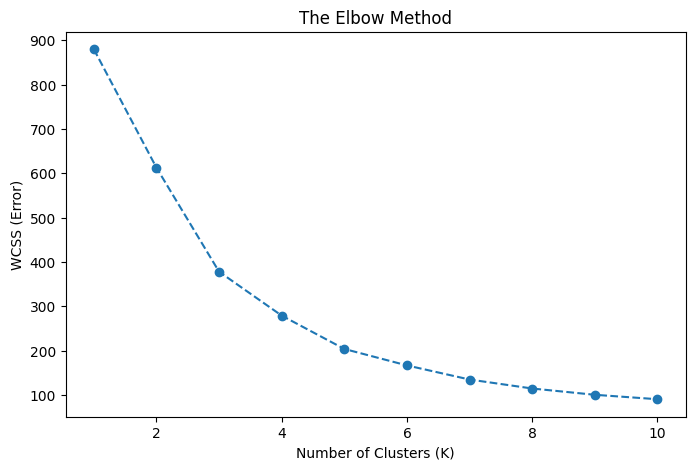

In [19]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Error)")
plt.show()

The curve bends around **K=4**: WCSS keeps dropping sharply up to that point, then flattens out, so adding a 5th or 6th cluster buys much less. K=4 is used for the final model.

In [20]:
K = 4
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0     74
1    303
2      4
3     59
Name: count, dtype: int64


## Create Customer Clusters

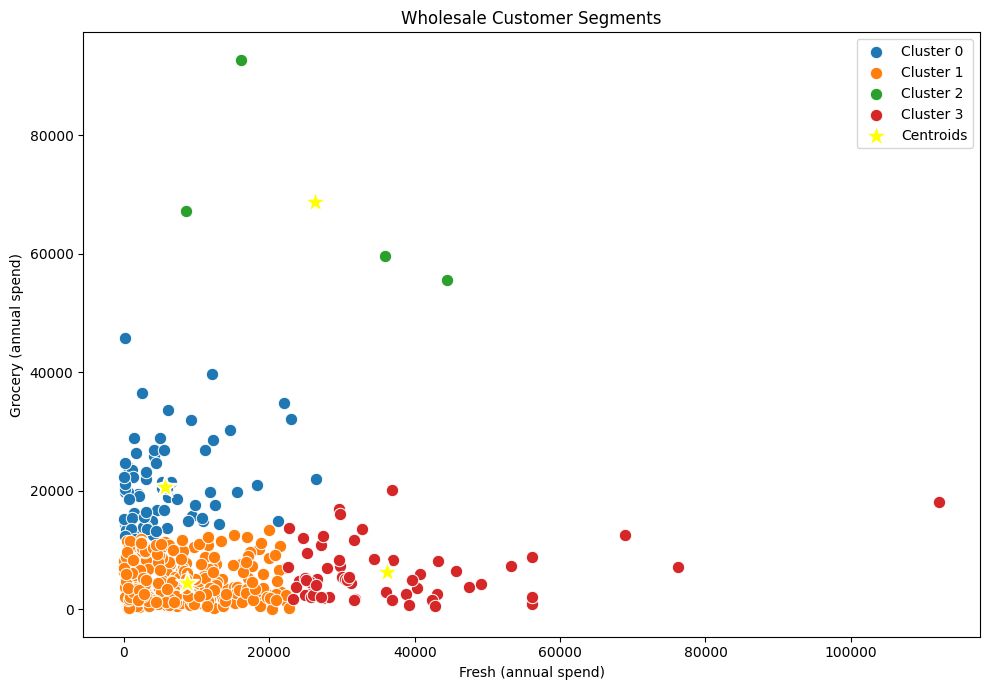

Centroids (Fresh, Grocery):
[[ 5643. 20582.]
 [ 8657.  4389.]
 [26272. 68812.]
 [36176.  6276.]]


In [21]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))

sns.scatterplot(data=df[df["Cluster"] == 0], x="Fresh", y="Grocery", s=80, label="Cluster 0")
sns.scatterplot(data=df[df["Cluster"] == 1], x="Fresh", y="Grocery", s=80, label="Cluster 1")
sns.scatterplot(data=df[df["Cluster"] == 2], x="Fresh", y="Grocery", s=80, label="Cluster 2")
sns.scatterplot(data=df[df["Cluster"] == 3], x="Fresh", y="Grocery", s=80, label="Cluster 3")

sns.scatterplot(x=centroids_original[:, 0], y=centroids_original[:, 1],
                s=300, color="yellow", marker="*", label="Centroids")

plt.title("Wholesale Customer Segments")
plt.xlabel("Fresh (annual spend)")
plt.ylabel("Grocery (annual spend)")
plt.legend()
plt.tight_layout()
plt.show()

print("Centroids (Fresh, Grocery):")
print(centroids_original.round(0))

## Describe Each Cluster

- **Cluster 0 - Grocery-Focused Retailers** (Fresh ~5643, Grocery ~20582, n=74). Low spend on Fresh, high spend on Grocery. Looks like small/medium retail shops stocking packaged goods rather than perishables.
- **Cluster 1 - Typical, Modest Spenders** (Fresh ~8657, Grocery ~4389, n=303). The largest group by far. Modest spend on both categories, the "average" customer.
- **Cluster 2 - Very High-Volume Accounts** (Fresh ~26272, Grocery ~68812, n=4). Only a handful of customers, but they spend far more than everyone else on both categories. Likely large chain buyers, worth handling separately from the rest.
- **Cluster 3 - Fresh-Focused Buyers** (Fresh ~36176, Grocery ~6276, n=59). High spend on Fresh, low spend on Grocery. Consistent with restaurants/cafes buying perishables rather than packaged goods.